In [1]:
from __future__ import annotations

import re
from dataclasses import dataclass, field
from pathlib import Path
from typing import Iterator

from docling.datamodel.base_models import InputFormat
from docling.datamodel.document import ConversionResult
from docling.datamodel.pipeline_options import PdfPipelineOptions
from docling.document_converter import DocumentConverter, PdfFormatOption
from docling_core.types.doc.base import CoordOrigin
from docling_core.types.doc.document import DoclingDocument
from docling_core.types.doc.page import TextCell
from PIL.Image import Image

In [2]:
from docling_parser.parser import set_full_page_ocr, word_level_ocr_options


pipeline_options = PdfPipelineOptions()
pipeline_options.do_ocr = True
pipeline_options.do_table_structure = True
# Required: without it docling drops the per-page cell layers we need.
pipeline_options.generate_parsed_pages = True
pipeline_options.generate_page_images = True
pipeline_options.images_scale = 2.0
ocr = True
word_level_ocr = True
force_full_page_ocr = True
ocr_options = None

if ocr_options is not None:
    pipeline_options.ocr_options = ocr_options
elif ocr and word_level_ocr:
    pipeline_options.ocr_options = word_level_ocr_options('rapidocr')
if force_full_page_ocr:
    # `from docling.datamodel.pipeline_options import OcrMode` only works on
    # docling >= 2.116; this helper falls back to the older boolean.
    set_full_page_ocr(pipeline_options.ocr_options)

converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)
    }
)

In [3]:
page_range = (1, 1)
DATA = Path.cwd().parent / "data" if Path.cwd().name == "notebooks" else Path("data")
SAMPLE = DATA / "sample.pdf"
SCAN = DATA / "scanned.pdf"
print(SAMPLE, SAMPLE.exists())

source = SCAN

kwargs = {"page_range": page_range} if page_range else {}
result = converter.convert(str(source), **kwargs)

[INFO] 2026-09-14 11:24:52,896 [RapidOCR] base.py:23: Using engine_name: onnxruntime


[INFO] 2026-09-14 11:24:52,922 [RapidOCR] download_file.py:60: File exists and is valid: /Users/ngam/dev/docling-parser/.venv/lib/python3.12/site-packages/rapidocr/models/PP-OCRv6_det_small.onnx


[INFO] 2026-09-14 11:24:52,923 [RapidOCR] main.py:63: Using /Users/ngam/dev/docling-parser/.venv/lib/python3.12/site-packages/rapidocr/models/PP-OCRv6_det_small.onnx


/Users/ngam/dev/docling-parser/data/sample.pdf True


[INFO] 2026-09-14 11:24:52,936 [RapidOCR] base.py:23: Using engine_name: onnxruntime


...

[INFO] 2026-09-14 11:24:52,937 [RapidOCR] main.py:63: Using /Users/ngam/dev/docling-parser/.venv/lib/python3.12/site-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx


[INFO] 2026-09-14 11:24:52,948 [RapidOCR] base.py:23: Using engine_name: onnxruntime


[INFO] 2026-09-14 11:24:52,957 [RapidOCR] download_file.py:60: File exists and is valid: /Users/ngam/dev/docling-parser/.venv/lib/python3.12/site-packages/rapidocr/models/PP-OCRv6_rec_small.onnx


[INFO] 2026-09-14 11:24:52,958 [RapidOCR] main.py:63: Using /Users/ngam/dev/docling-parser/.venv/lib/python3.12/site-packages/rapidocr/models/PP-OCRv6_rec_small.onnx


Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

In [4]:
for page in result.pages:
    print(page.page_no)
    print(page.parsed_page.word_cells)

1
[TextCell(index=0, rgba=ColorRGBA(r=0, g=0, b=0, a=255), rect=BoundingRectangle(r_x0=15.0, r_y0=256.6666666666667, r_x1=35.333333333333336, r_y1=256.6666666666667, r_x2=35.333333333333336, r_y2=216.33333333333334, r_x3=15.0, r_y3=216.33333333333334, coord_origin=<CoordOrigin.TOPLEFT: 'TOPLEFT'>), text='2024', orig='2024', text_direction=<TextDirection.LEFT_TO_RIGHT: 'left_to_right'>, confidence=0.99999, from_ocr=True), TextCell(index=1, rgba=ColorRGBA(r=0, g=0, b=0, a=255), rect=BoundingRectangle(r_x0=217.0, r_y0=240.66666666666666, r_x1=267.3333333333333, r_y1=240.66666666666666, r_x2=267.3333333333333, r_y2=222.33333333333334, r_x3=217.0, r_y3=222.33333333333334, coord_origin=<CoordOrigin.TOPLEFT: 'TOPLEFT'>), text='Docling', orig='Docling', text_direction=<TextDirection.LEFT_TO_RIGHT: 'left_to_right'>, confidence=0.99989, from_ocr=True), TextCell(index=2, rgba=ColorRGBA(r=0, g=0, b=0, a=255), rect=BoundingRectangle(r_x0=275.0, r_y0=241.0, r_x1=343.6666666666667, r_y1=241.0, r_x2=3

In [5]:
result.pages[0].parsed_page.word_cells

[TextCell(index=0, rgba=ColorRGBA(r=0, g=0, b=0, a=255), rect=BoundingRectangle(r_x0=15.0, r_y0=256.6666666666667, r_x1=35.333333333333336, r_y1=256.6666666666667, r_x2=35.333333333333336, r_y2=216.33333333333334, r_x3=15.0, r_y3=216.33333333333334, coord_origin=<CoordOrigin.TOPLEFT: 'TOPLEFT'>), text='2024', orig='2024', text_direction=<TextDirection.LEFT_TO_RIGHT: 'left_to_right'>, confidence=0.99999, from_ocr=True),
 TextCell(index=1, rgba=ColorRGBA(r=0, g=0, b=0, a=255), rect=BoundingRectangle(r_x0=217.0, r_y0=240.66666666666666, r_x1=267.3333333333333, r_y1=240.66666666666666, r_x2=267.3333333333333, r_y2=222.33333333333334, r_x3=217.0, r_y3=222.33333333333334, coord_origin=<CoordOrigin.TOPLEFT: 'TOPLEFT'>), text='Docling', orig='Docling', text_direction=<TextDirection.LEFT_TO_RIGHT: 'left_to_right'>, confidence=0.99989, from_ocr=True),
 TextCell(index=2, rgba=ColorRGBA(r=0, g=0, b=0, a=255), rect=BoundingRectangle(r_x0=275.0, r_y0=241.0, r_x1=343.6666666666667, r_y1=241.0, r_x2=3

## Why `word_cells` was empty

`word_cells` is filled from the **PDF text layer**, and docling's OCR
post-processing never writes to it:

- `scanned.pdf` is an image-only PDF — no text layer, so docling-parse produces
  0 word cells and 0 char cells before OCR even starts.
- `docling/models/base_ocr_model.py:385` assigns OCR results to
  `parsed_page.textline_cells` only, and in `OcrMode.FULL_PAGE` it *clears*
  `word_cells` (comment: "PDF-extracted word/char cells are unreliable").

So with a stock docling engine, `word_cells` stays `[]` on a scanned page no
matter what — the OCR output is in **`textline_cells`**, at line granularity.

The word-level engines in this repo return one cell per word, so they also mirror
those cells into `word_cells` (`word_cells.py: PublishWordCellsMixin`) — the field
you looked for now works, as the next cell shows.

In [6]:
pp = result.pages[0].parsed_page

print(f"engine         = {pipeline_options.ocr_options.kind}")
print(f"char_cells     = {len(pp.char_cells)}")
print(f"word_cells     = {len(pp.word_cells)}")
print(f"textline_cells = {len(pp.textline_cells)}   "
      f"(from_ocr: {sum(c.from_ocr for c in pp.textline_cells)})")
print()
for cell in pp.word_cells[:5]:
    print(f"{cell.text[:40]:<42} conf={cell.confidence:.2f} {cell.rect.to_bounding_box()}")

engine         = rapidocr_words
char_cells     = 0
word_cells     = 307
textline_cells = 307   (from_ocr: 307)

2024                                       conf=1.00 l=15.0 t=216.33333333333334 r=35.333333333333336 b=256.6666666666667 coord_origin=<CoordOrigin.TOPLEFT: 'TOPLEFT'>
Docling                                    conf=1.00 l=217.0 t=222.33333333333334 r=267.3333333333333 b=240.66666666666666 coord_origin=<CoordOrigin.TOPLEFT: 'TOPLEFT'>
Technical                                  conf=1.00 l=275.0 t=222.33333333333334 r=343.6666666666667 b=241.0 coord_origin=<CoordOrigin.TOPLEFT: 'TOPLEFT'>
Report                                     conf=1.00 l=351.3333333333333 t=222.66666666666666 r=401.6666666666667 b=241.33333333333334 coord_origin=<CoordOrigin.TOPLEFT: 'TOPLEFT'>
9                                          conf=1.00 l=15.333333333333334 t=267.0 r=35.666666666666664 b=277.6666666666667 coord_origin=<CoordOrigin.TOPLEFT: 'TOPLEFT'>


## Cutting lines into words (the fallback path)

With a *line-level* engine — stock `EasyOcrOptions()` / `RapidOcrOptions()`, or
docling's auto pick — this is the only way to get word boxes: slice each line
proportionally to character offsets. It is what `parse_pdf` falls back to
(`parser.py:_split_line`), written out inline here.

Since cell 2 above configures a **word-level** engine, the cells are already
single words and the loop is a passthrough — one output word per input cell, with
the box unchanged. Set `word_level_ocr = False` in cell 2 to see it actually
split.

In [7]:
page = result.pages[0]
page_height = page.size.height

words = []  # (text, l, t, r, b, confidence)
for cell in page.parsed_page.textline_cells:
    if not cell.text.strip():
        continue
    bbox = cell.rect.to_bounding_box()
    if bbox.coord_origin == CoordOrigin.BOTTOMLEFT:
        bbox = bbox.to_top_left_origin(page_height)

    n_chars = len(cell.text)
    span = bbox.r - bbox.l
    for m in re.finditer(r"\S+", cell.text):
        start, end = m.span()
        words.append((
            m.group(),
            bbox.l + span * start / n_chars,
            bbox.t,
            bbox.l + span * end / n_chars,
            bbox.b,
            cell.confidence,
        ))

print(f"{len(page.parsed_page.textline_cells)} OCR lines -> {len(words)} words\n")
for text, l, t, r, b, conf in words[:10]:
    print(f"{text:<14} l={l:7.1f} t={t:7.1f} r={r:7.1f} b={b:7.1f}  conf={conf:.2f}")

307 OCR lines -> 307 words

2024           l=   15.0 t=  216.3 r=   35.3 b=  256.7  conf=1.00
Docling        l=  217.0 t=  222.3 r=  267.3 b=  240.7  conf=1.00
Technical      l=  275.0 t=  222.3 r=  343.7 b=  241.0  conf=1.00
Report         l=  351.3 t=  222.7 r=  401.7 b=  241.3  conf=1.00
9              l=   15.3 t=  267.0 r=   35.7 b=  277.7  conf=1.00
Dec            l=   15.0 t=  280.7 r=   35.3 b=  312.3  conf=0.85
Version        l=  286.0 t=  277.7 r=  313.0 b=  288.3  conf=1.00
1.0            l=  318.3 t=  277.7 r=  329.0 b=  288.3  conf=1.00
Christoph      l=  119.3 t=  308.3 r=  160.7 b=  320.3  conf=1.00
Auer           l=  165.3 t=  308.3 r=  185.7 b=  320.3  conf=1.00


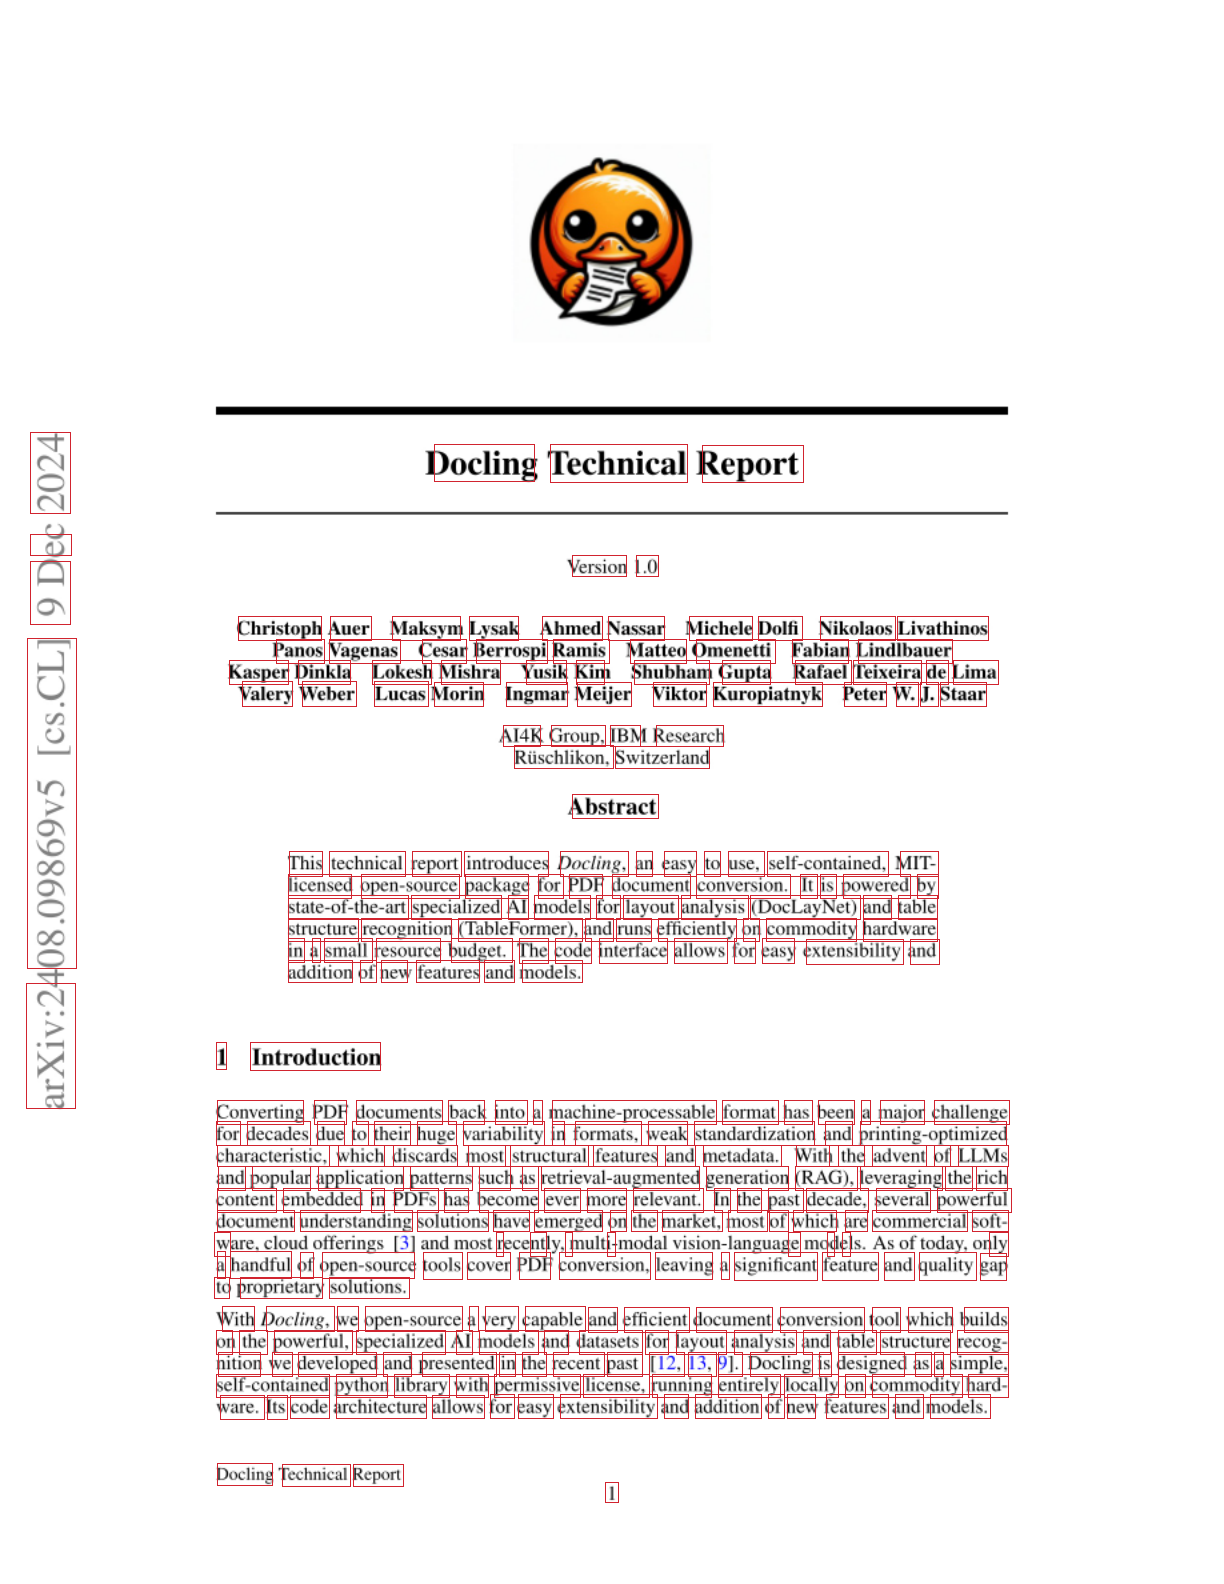

In [8]:
from PIL import ImageDraw

from IPython.display import display

img = page.image.convert("RGB")
scale = img.width / page.size.width  # px per PDF point
draw = ImageDraw.Draw(img)
for text, l, t, r, b, conf in words:
    draw.rectangle((l * scale, t * scale, r * scale, b * scale), outline="#d1242f", width=1)

display(img)

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

309 words; estimated=20


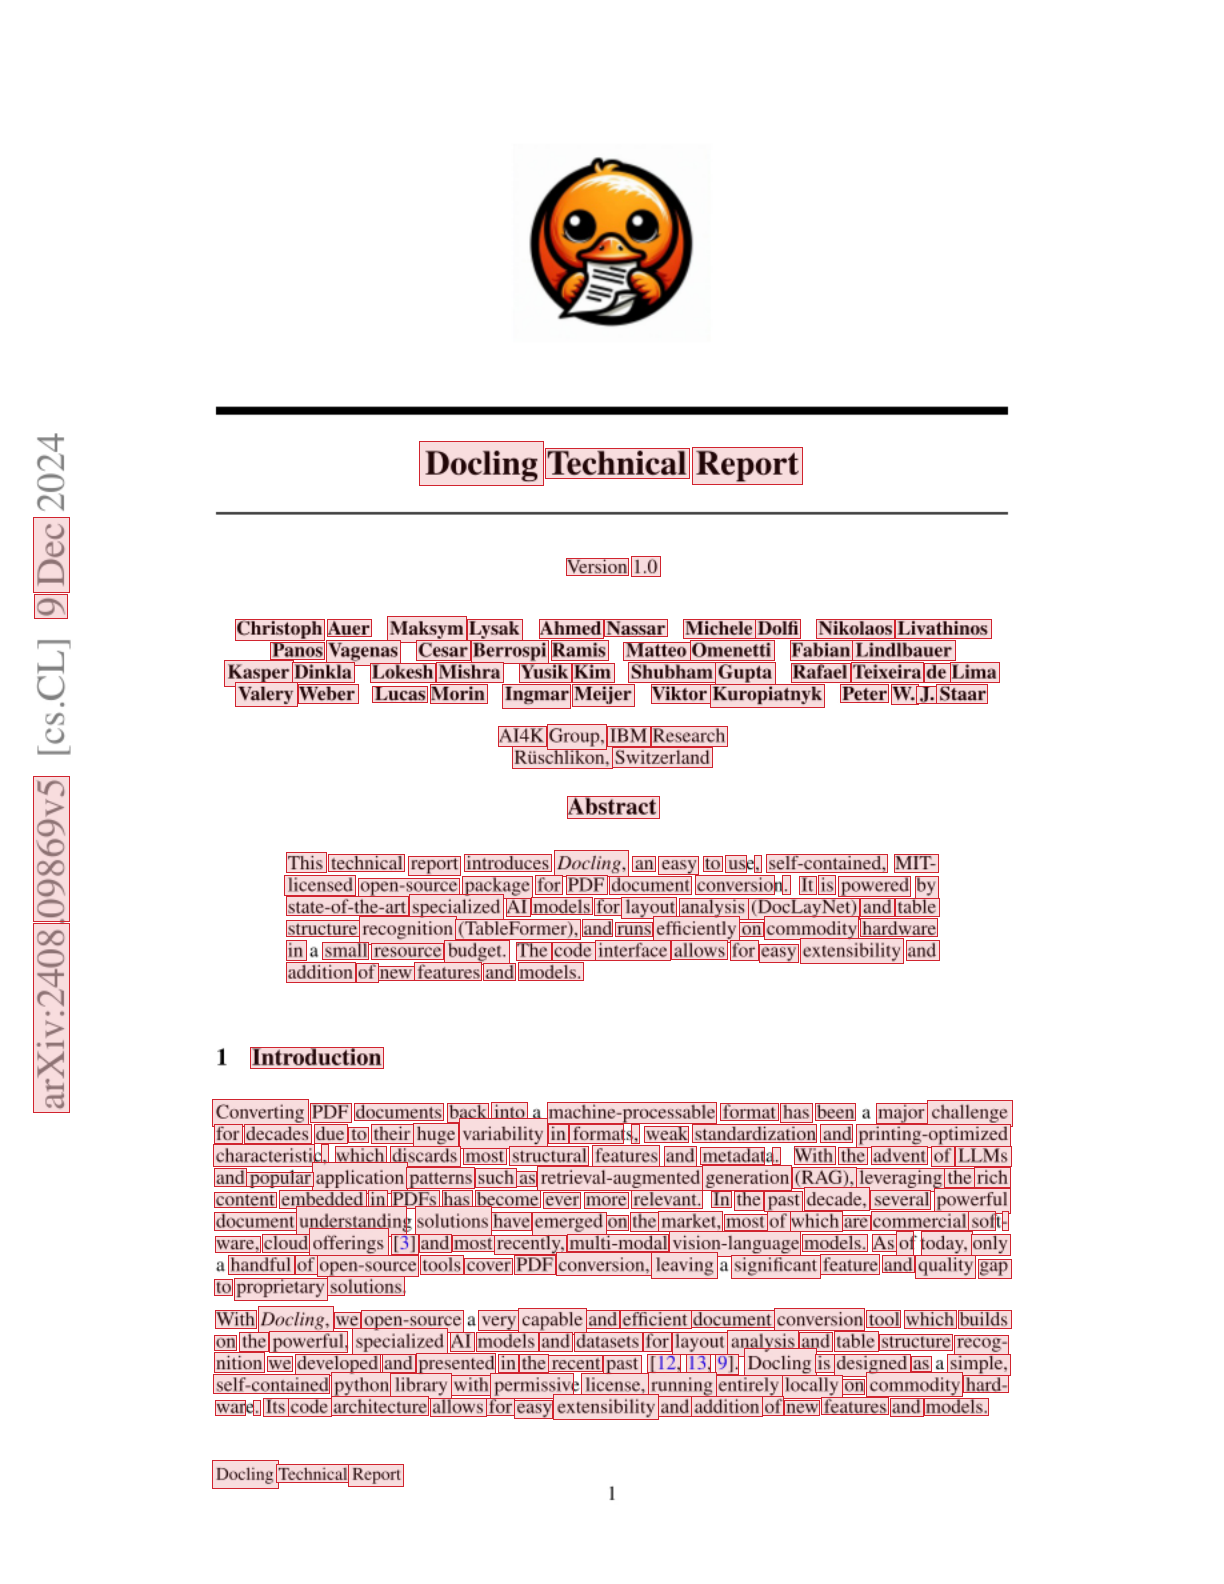

In [9]:
# Same result in one call, for either a scanned or a digital PDF:
from docling_parser import draw_word_boxes, parse_pdf

parsed = parse_pdf(SCAN, ocr=True, force_full_page_ocr=True, page_range=(1, 1), word_level_ocr=True, ocr_engine="easyocr")
p = parsed.pages[0]
print(f"{len(p.words)} words; estimated={sum(w.estimated for w in p.words)}")
display(draw_word_boxes(p))

## The engines, and why each needs a different fix

- **EasyOCR**: its detector finds words, but docling calls `reader.readtext(im)`
  with no arguments (`easyocr_model.py:219`), so the default `width_ths=0.5`
  merges them into lines. `easyocr_words.py` forwards `width_ths=0.0`.
- **RapidOCR**: DBNet detects lines by design — nothing to un-merge — but
  `return_word_box=True` splits each line via the recognizer's CTC alignment.
  `rapidocr_words.py` sets it and flattens `word_results` back into
  `boxes`/`txts`/`scores`, so docling's own cell loop emits one cell per word.

Both register in docling's OCR factory (`easyocr_words`, `rapidocr_words`) and
publish to `word_cells`. `parse_pdf` uses them by default; pass
`word_level_ocr=False` for the splitting fallback.

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

309 words, 289 measured / 20 still estimated
word_cells=299  textline_cells=299
  'Docling'        conf=0.99
  'Technical'      conf=1.00
  'Report'         conf=1.00
  'g'              conf=0.15
  'Version'        conf=0.86


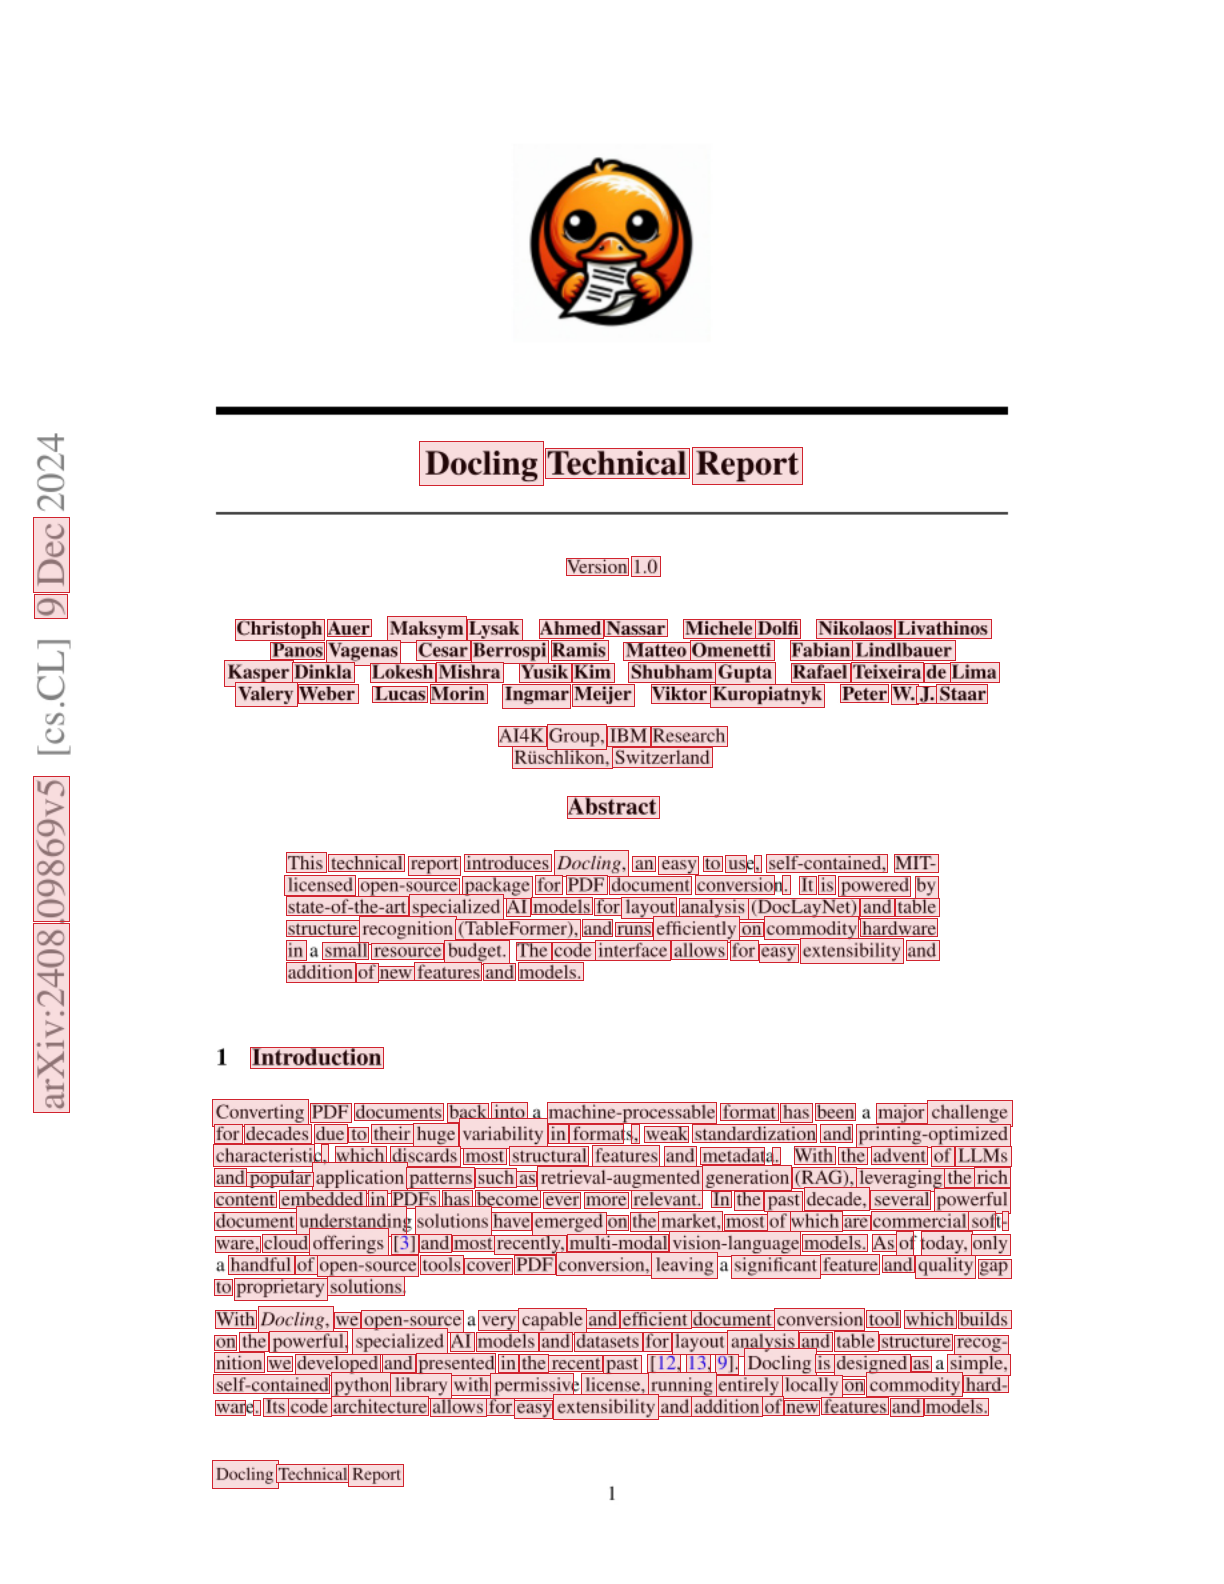

In [10]:
wl = parse_pdf(SCAN, ocr=True, word_level_ocr=True, force_full_page_ocr=True, page_range=(1, 1))
wp = wl.pages[0]
measured = sum(not w.estimated for w in wp.words)
print(f"{len(wp.words)} words, {measured} measured / {len(wp.words) - measured} still estimated")

# docling's own cell layers, straight off the page:
pp = wl.conversion.pages[0].parsed_page
print(f"word_cells={len(pp.word_cells)}  textline_cells={len(pp.textline_cells)}")
for cell in pp.word_cells[:5]:
    print(f"  {cell.text!r:<16} conf={cell.confidence:.2f}")

display(draw_word_boxes(wp))

## EasyOCR vs RapidOCR

RapidOCR needs a different trick: its DBNet detector is trained on text *lines*,
so there is no grouping step to disable. Instead `return_word_box=True` makes the
recognizer split each line using its own CTC alignment. `rapidocr_words.py` sets
that flag and flattens the word results back into `boxes`/`txts`/`scores`, so
docling's own cell-building loop emits one cell per word.

Pick with `ocr_engine="easyocr" | "rapidocr"`.

In [11]:
import time

# ground truth: the same page's digital text layer
gt = parse_pdf(SAMPLE, ocr=False, page_range=(1, 1)).pages[0].words


def iou(a, b):
    ix = min(a.right, b.right) - max(a.left, b.left)
    iy = min(a.bottom, b.bottom) - max(a.top, b.top)
    if ix <= 0 or iy <= 0:
        return 0.0
    inter = ix * iy
    return inter / (a.width * a.height + b.width * b.height - inter)


pages = {}
for engine in ("easyocr", "rapidocr"):
    t = time.perf_counter()
    p = parse_pdf(SCAN, ocr=True, ocr_engine=engine,
                  force_full_page_ocr=True, page_range=(1, 1)).pages[0]
    elapsed = time.perf_counter() - t
    pages[engine] = p

    ious = sorted(iou(w, best) for w in p.words
                  for best in [max(gt, key=lambda g: iou(w, g))]
                  if iou(w, best) > 0.1 and best.text == w.text)
    print(f"{engine:<9} {len(p.words):>4} boxes  measured={sum(not w.estimated for w in p.words):>4}  "
          f"text-match={len(ious):>3}/{len(gt)}  median IoU={ious[len(ious) // 2]:.3f}  {elapsed:5.1f}s")

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

easyocr    309 boxes  measured= 289  text-match=256/315  median IoU=0.744    9.4s


[INFO] 2026-09-14 11:25:28,602 [RapidOCR] base.py:23: Using engine_name: onnxruntime


[INFO] 2026-09-14 11:25:28,610 [RapidOCR] download_file.py:60: File exists and is valid: /Users/ngam/dev/docling-parser/.venv/lib/python3.12/site-packages/rapidocr/models/PP-OCRv6_det_small.onnx


...

[INFO] 2026-09-14 11:25:28,668 [RapidOCR] base.py:23: Using engine_name: onnxruntime


[INFO] 2026-09-14 11:25:28,681 [RapidOCR] download_file.py:60: File exists and is valid: /Users/ngam/dev/docling-parser/.venv/lib/python3.12/site-packages/rapidocr/models/PP-OCRv6_rec_small.onnx


[INFO] 2026-09-14 11:25:28,682 [RapidOCR] main.py:63: Using /Users/ngam/dev/docling-parser/.venv/lib/python3.12/site-packages/rapidocr/models/PP-OCRv6_rec_small.onnx


Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

rapidocr   307 boxes  measured= 307  text-match=292/315  median IoU=0.683    4.0s


easyocr
rapidocr


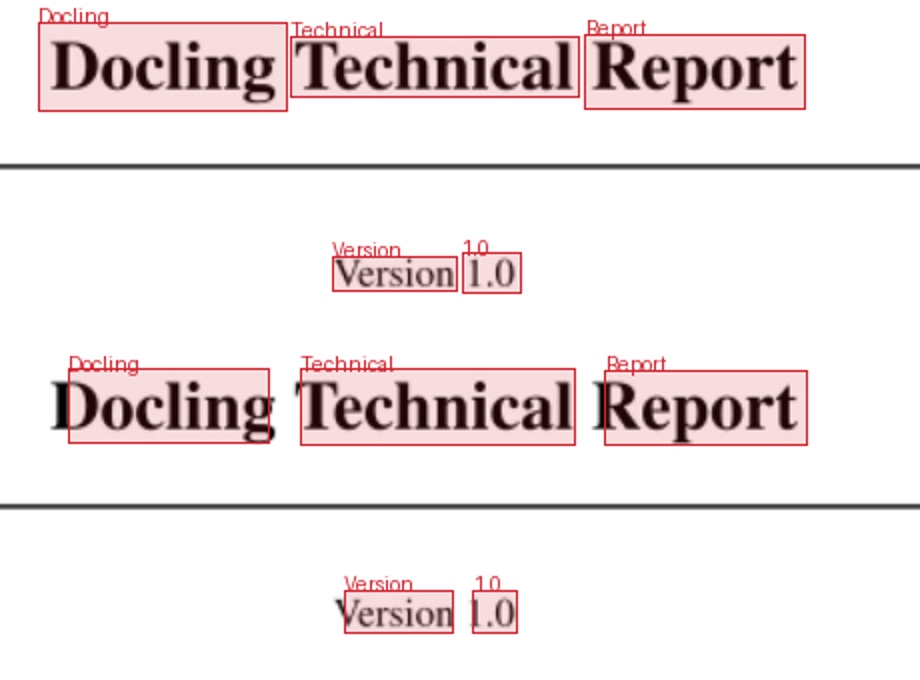

In [12]:
from PIL import Image

# side by side on the title block
crop_pt = (200, 215, 430, 300)
tiles = []
for engine, p in pages.items():
    img = draw_word_boxes(p, show_text=True)
    s = p.image_scale
    c = img.crop(tuple(int(v * s) for v in crop_pt))
    tiles.append(c.resize((c.width * 2, c.height * 2)))
    print(engine)

stacked = Image.new("RGB", (tiles[0].width, sum(t.height for t in tiles)), "white")
y = 0
for t in tiles:
    stacked.paste(t, (0, y))
    y += t.height
display(stacked)  # top: easyocr, bottom: rapidocr